In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,
    confusion_matrix,classification_report,roc_auc_score)

In [25]:
df = pd.read_csv("/content/onlinefraud.csv")

In [26]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1927241 entries, 0 to 1927240
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         float64
 10  isFlaggedFraud  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 161.7+ MB


In [28]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,1
isFraud,1


In [29]:
print(df["isFraud"].value_counts())

isFraud
0.0    1925338
1.0       1902
Name: count, dtype: int64


In [30]:
print(df["isFraud"].value_counts(normalize=True) * 100)

isFraud
0.0    99.90131
1.0     0.09869
Name: proportion, dtype: float64


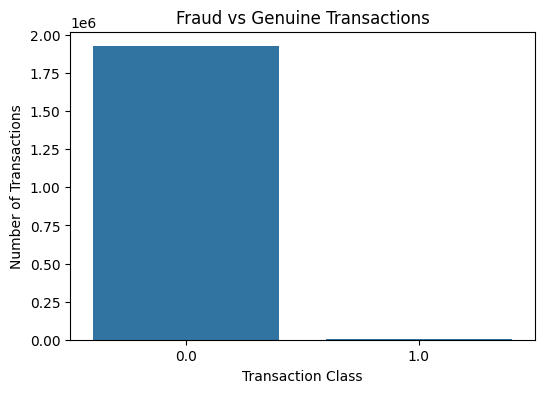

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(x="isFraud", data=df)

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()

In [32]:
fraud_type = df.groupby("type")["isFraud"].sum()

print(fraud_type)

type
CASH_IN       0.0
CASH_OUT    958.0
DEBIT         0.0
PAYMENT       0.0
TRANSFER    944.0
Name: isFraud, dtype: float64


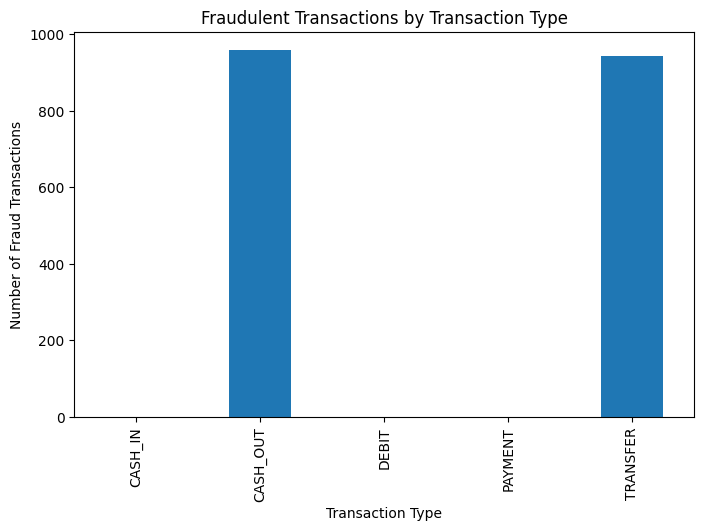

In [33]:
plt.figure(figsize=(8,5))

fraud_type.plot(kind="bar")

plt.title("Fraudulent Transactions by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Fraud Transactions")

plt.show()

In [34]:
print(df.groupby("isFraud")["amount"].mean())

isFraud
0.0    1.592939e+05
1.0    1.273468e+06
Name: amount, dtype: float64


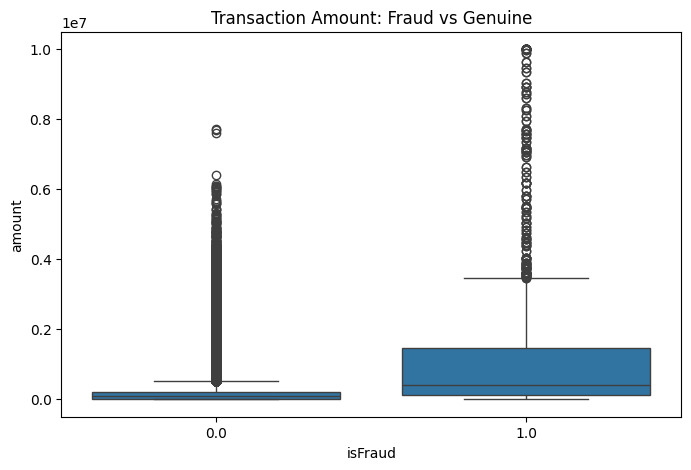

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(x="isFraud", y="amount", data=df)

plt.title("Transaction Amount: Fraud vs Genuine")

plt.show()

In [36]:
df["balance_change_orig"] = (
    df["oldbalanceOrg"] - df["newbalanceOrig"]
)

df["balance_change_dest"] = (
    df["newbalanceDest"] - df["oldbalanceDest"]
)

In [37]:
df.dropna(subset=["isFraud"], inplace=True)
X = df.drop(columns=["isFraud", "nameOrig", "nameDest"])
X = pd.get_dummies(X, columns=["type"], drop_first=True)

y = df["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [40]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=50, n_jobs=-1,
                       random_state=42)

In [41]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Classification Report:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9990141342022789
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    385068
         1.0       0.00      0.00      0.00       380

    accuracy                           1.00    385448
   macro avg       0.50      0.50      0.50    385448
weighted avg       1.00      1.00      1.00    385448



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

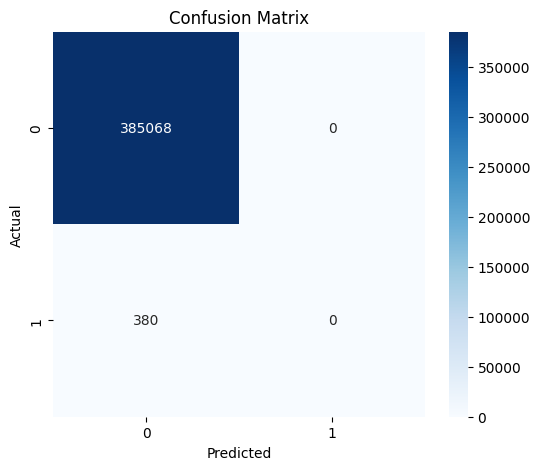

In [42]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [43]:
y_probability = model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_probability)

print("ROC-AUC Score:", roc_auc)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


ROC-AUC Score: 0.8196825078878754


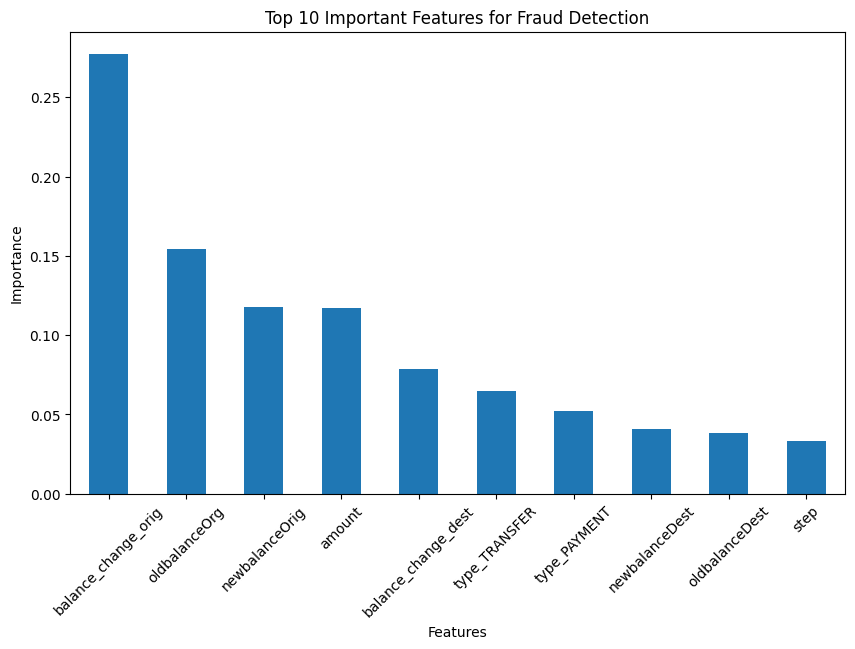

In [44]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
importance.plot(kind="bar")

plt.title("Top 10 Important Features for Fraud Detection")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)

plt.show()

In [45]:
sample = X_test.iloc[0:1]

prediction = model.predict(
    scaler.transform(sample)
)

if prediction[0] == 1:
    print("⚠️ FRAUDULENT TRANSACTION DETECTED")
else:
    print("✅ GENUINE TRANSACTION")

✅ GENUINE TRANSACTION


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
